# 2nd Hidden Layer -- Evaluate Realistic-Perturbation Checkpoints

This is the realistic-task (SHD & SSC) counterpart of the perturbation-folder
`2ndLayer_eval_on_perturbedModel.ipynb`. The realistic perturbation replaces a
fraction **f** of the second hidden-layer spikes with random spikes
(spike count per neuron preserved); **f** sweeps from 0 (untouched) to 1 (all
temporal structure destroyed).

Models trained with a *little* perturbation tend to score better at their matched
evaluation level. This notebook isolates that effect: for each dataset variant it
loads checkpoints **trained at several small fractions** and evaluates each one
across the **entire** f-sweep (eval-on-checkpoint), rather than training a fresh
model per level. Every plot overlays the checkpoints against the no-perturbation
reference:

- **Checkpoints** -- models trained at `f = 0.2, 0.4` (solid, deepening shade).
- **No perturbation** -- a clean-trained model (`f = 0`) swept over f at eval
  time (dashed, lightest shade).

Each dataset is plotted twice -- once for the **no-delay** model and once for the
**delay** model. Two encodings share the axis: **hue** = dataset variant and
**colour depth** = the checkpoint's training level.

- **SHD** -- variants Whole / Part / Norm.
- **SSC** -- variants Part / Norm (SSC has no Whole variant).

The eval-on-checkpoint sweeps are read from `log_eval_on_perturbatedModel/`; the
baselines come from each dataset's `log/` folder. Sweep files that have not been
generated yet are skipped so the notebook stays runnable as results accumulate.


In [9]:
# Setup: locate the realistic SHD / SSC log folders and the eval-on-checkpoint
# sweeps so the plots below can read the pre-computed results.
import json
from pathlib import Path

import numpy as np

BASE_DIR = Path.cwd()
assert (BASE_DIR / "shd").is_dir() and (BASE_DIR / "ssc").is_dir(), (
    "Run this notebook from my_project/exp_fixed_weight_perturbation/"
    "result_visualization/realistic/ so the shd / ssc packages and their "
    "per-layer log folders are reachable."
)

# Spike-train variants available for each dataset (SSC has no 'whole' variant).
DATASET_VARIANTS = {
    "shd": ("whole", "part", "norm"),
    "ssc": ("part", "norm"),
}

# Checkpoint training levels to overlay (a model trained at each fraction f).
REALISTIC_LEVELS = [0.2, 0.4, 0.6]

# Which hidden layer this notebook evaluates.
LAYER_TAG = "2ndLayer"
LAYER_TITLE = "2nd Layer"

# Directory holding the eval-on-checkpoint sweep results.
EVAL_LOG_DIR = Path("log_eval_on_perturbatedModel")


def baseline_path(dataset, variant, delay_tag):
    """No-perturbation reference: a clean-trained model swept over f at eval time."""
    if LAYER_TAG == "1stLayer":
        name = f"{dataset}_{variant}_{delay_tag}_hidden_perturbation_results.json"
    else:
        name = (
            f"{dataset}_{LAYER_TAG}_{variant}_{delay_tag}"
            "_hidden_perturbation_results.json"
        )
    return Path(dataset) / f"{LAYER_TAG}_log" / name


def evalon_path(dataset, variant, delay_tag, level):
    """Eval-on-checkpoint sweep for a model trained at fraction ``level``."""
    name = f"{dataset}_{LAYER_TAG}_{variant}_{delay_tag}_evalon_f{level}.json"
    return EVAL_LOG_DIR / name


print(f"Eval results dir: {EVAL_LOG_DIR.resolve()}")

Eval results dir: D:\IC_2025\IRP\workspace\my_project\exp_fixed_weight_perturbation\result_visualization\realistic\log_eval_on_perturbatedModel


## Comparison: checkpoints trained at several perturbation levels

Each plot overlays, on a single axis, the same eval-on-checkpoint experiment for
**several checkpoints trained at different fractions f**, plus the no-perturbation
reference:

- **Solid lines** -- a checkpoint trained at a given fraction f, then evaluated
  across the whole f-sweep (read from `log_eval_on_perturbatedModel/`). One solid
  curve per training level.
- **Dashed, &#10005;** -- the **no-perturbation** model: a single clean-trained
  checkpoint evaluated across the whole f-sweep (the
  `{dataset}/log/..._hidden_perturbation_results.json` files).

Within one dataset variant the curves keep the same hue; the no-perturbation
baseline is the lightest shade and each higher training level is drawn in a
progressively deeper shade of that hue. A **no-delay** and a **delay** plot are
produced for each dataset, so the effect of the training-perturbation level can
be read off directly against the no-perturbation baseline.


In [10]:
# Plotting helpers (shared with the perturbation notebooks). Dataset variant is
# encoded by hue; the checkpoint's training level is encoded by colour depth.
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

COLORS = {"Whole": "#1f77b4", "Part": "#2ca02c", "Norm": "#d62728"}
DS_LABEL = {"whole": "Whole", "part": "Part", "norm": "Norm"}


def shade(base_color, frac):
    """Return a lighter/darker variant of ``base_color`` keeping its hue.

    ``frac`` in ``[0, 1]`` maps the lightest variant (0, blended toward white)
    to the darkest variant (1, blended toward black), so higher perturbation
    levels can be drawn in a deeper shade of the same colour.
    """
    rgb = np.array(mcolors.to_rgb(base_color))
    lightest = rgb + (1.0 - rgb) * 0.55
    darkest = rgb * 0.45
    return tuple(lightest + (darkest - lightest) * frac)


def _depth_fracs(num_levels):
    """Depth positions for the baseline + each level (light -> dark).

    Index 0 is the no-perturbation baseline (lightest); the ``num_levels``
    checkpoint curves then deepen as the training level increases.
    """
    total = num_levels + 1
    return [j / (total - 1) for j in range(total)]


def load_sweep(path, key_type=int):
    """Load a sweep JSON -> (levels, means_pct, stds_pct)."""
    with open(path) as fh:
        raw = json.load(fh)
    levels = sorted(key_type(k) for k in raw)
    means = np.array([raw[str(lvl)]["mean"] for lvl in levels]) * 100
    stds = np.array([raw[str(lvl)]["std"] for lvl in levels]) * 100
    return levels, means, stds


def plot_multilevel(level_series, baseline_paths, variants, key_type, xlabel,
                    title, xlim, level_title):
    """Overlay eval-on-checkpoint sweeps for several training levels on one axis.

    Dataset variant is encoded by colour (hue); the checkpoint's *training*
    perturbation level is encoded by the depth of that colour -- the
    no-perturbation baseline is the lightest shade (dashed) and each deeper shade
    is a checkpoint trained at a higher level. ``level_series`` is a list of
    ``(level_label, paths_by_variant)`` tuples in ascending level order. Sweep
    files that do not exist yet are skipped, so the notebook stays runnable while
    the realistic experiments are still being generated.
    """
    fracs = _depth_fracs(len(level_series))
    fig, ax = plt.subplots(figsize=(7, 5))
    plotted_any = False
    for ds in variants:
        base = COLORS[DS_LABEL[ds]]
        baseline = baseline_paths[ds]
        if baseline.exists():
            bx, bmeans, _ = load_sweep(baseline, key_type)
            ax.plot(bx, bmeans, linestyle="--", marker="x",
                    color=shade(base, fracs[0]), markersize=6, linewidth=1.6)
            plotted_any = True
        for idx, (_, paths) in enumerate(level_series):
            path = paths[ds]
            if not path.exists():
                continue
            x, means, _ = load_sweep(path, key_type)
            ax.plot(x, means, linestyle="-", marker="o",
                    color=shade(base, fracs[idx + 1]), markersize=4, linewidth=1.6)
            plotted_any = True

    if not plotted_any:
        plt.close(fig)
        print(f"[skip] {title}: no sweep files found yet.")
        return None

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Test Accuracy (%)")
    ax.set_xlim(*xlim)
    ax.set_ylim(0, None)
    ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)

    # Depth legend: neutral grey ramp conveying the light->dark level ordering.
    grey = "#7f7f7f"
    level_handles = [
        mlines.Line2D([], [], color=shade(grey, fracs[0]), marker="x",
                      linestyle="--", markersize=6, linewidth=1.6,
                      label="no perturbation")
    ]
    level_handles += [
        mlines.Line2D([], [], color=shade(grey, fracs[idx + 1]), marker="o",
                      linestyle="-", markersize=4, linewidth=1.6,
                      label=f"ckpt {label}")
        for idx, (label, _) in enumerate(level_series)
    ]
    ds_handles = [
        mlines.Line2D([], [], color=COLORS[DS_LABEL[ds]], linewidth=2.5,
                      label=DS_LABEL[ds])
        for ds in variants
    ]

    level_legend = ax.legend(handles=level_handles, loc="upper right",
                             framealpha=0.9, title=level_title, fontsize=8)
    ax.add_artist(level_legend)
    ax.legend(handles=ds_handles, loc="lower left", framealpha=0.9,
              title="Dataset", fontsize=8)

    fig.tight_layout()
    plt.show()
    return fig

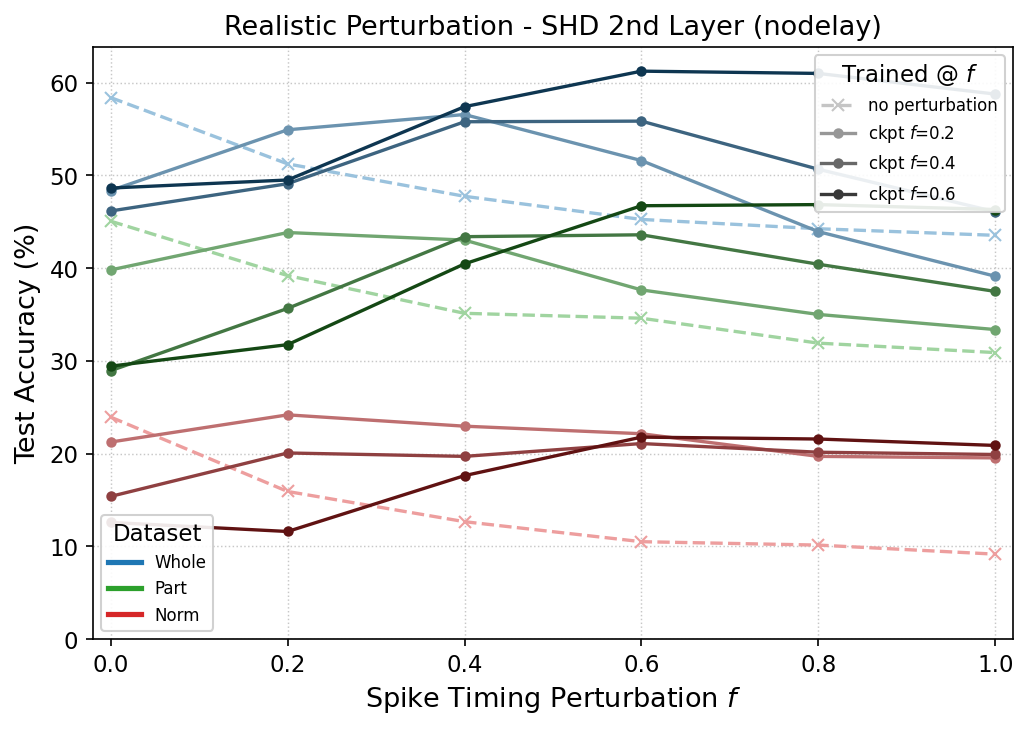

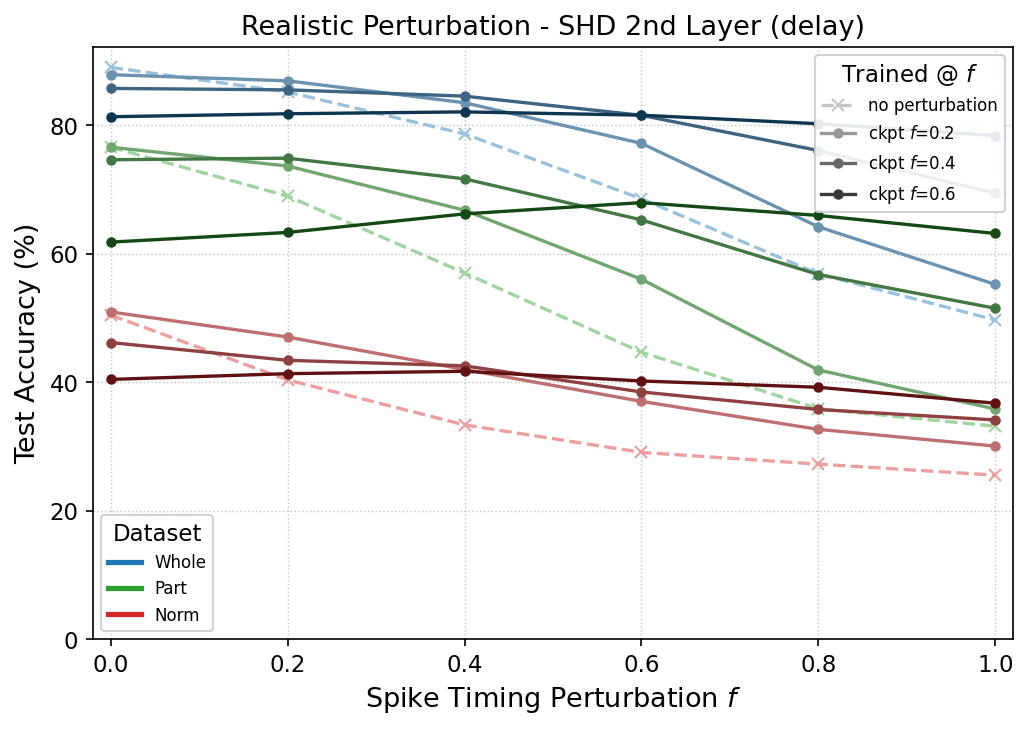

In [11]:
# SHD checkpoints to overlay (a model trained at each fraction f),
# one plot for the no-delay model and one for the delay model.
dataset = "shd"
variants = DATASET_VARIANTS[dataset]
for delay_tag in ("nodelay", "delay"):
    level_series = [
        (rf"$f$={level}", {
            variant: evalon_path(dataset, variant, delay_tag, level)
            for variant in variants
        })
        for level in REALISTIC_LEVELS
    ]
    baseline_paths = {
        variant: baseline_path(dataset, variant, delay_tag)
        for variant in variants
    }
    plot_multilevel(
        level_series, baseline_paths, variants, float,
        xlabel=r"Spike Timing Perturbation $f$",
        title=f"Realistic Perturbation - SHD {LAYER_TITLE} ({delay_tag})",
        xlim=(-0.02, 1.02),
        level_title=r"Trained @ $f$",
    )

In [12]:
# SSC checkpoints to overlay (a model trained at each fraction f),
# one plot for the no-delay model and one for the delay model.
dataset = "ssc"
variants = DATASET_VARIANTS[dataset]
for delay_tag in ("nodelay", "delay"):
    level_series = [
        (rf"$f$={level}", {
            variant: evalon_path(dataset, variant, delay_tag, level)
            for variant in variants
        })
        for level in REALISTIC_LEVELS
    ]
    baseline_paths = {
        variant: baseline_path(dataset, variant, delay_tag)
        for variant in variants
    }
    plot_multilevel(
        level_series, baseline_paths, variants, float,
        xlabel=r"Spike Timing Perturbation $f$",
        title=f"Realistic Perturbation - SSC {LAYER_TITLE} ({delay_tag})",
        xlim=(-0.02, 1.02),
        level_title=r"Trained @ $f$",
    )

[skip] Realistic Perturbation - SSC 2nd Layer (nodelay): no sweep files found yet.
[skip] Realistic Perturbation - SSC 2nd Layer (delay): no sweep files found yet.
